In [13]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

# Przygotowanie danych

### Pobranie danych

In [ ]:
signal = np.loadtxt("assets/signal.csv")

### Wygenerowanie danych

In [14]:
def impsim(fs, nx, fmod, amp_imp, f_center, bandwidth, shift):
    """
        fs - częstotliwość próbkowania
        nx - liczba próbek w sygnale wynikowym
        fmod - częstotliwość powtarzania impulsów (lub lista dla wielu)
        amp_imp - amplituda impulsów
        f_center - środkowa częstotliwość pasma
        bandwidth - szerokość pasma wokół f_center
        shift - przesunięcie fazowe sygnału
    """
    #konwersja parametrów do tablic w przypadku jednej wartości
    fmod = np.atleast_1d(fmod)
    amp_imp = np.atleast_1d(amp_imp)
    f_center = np.atleast_1d(f_center)
    bandwidth = np.atleast_1d(bandwidth)
    shift = np.atleast_1d(shift)
    
    # funkcja pomocnicza impulsu tłumionego 
    def fnx(x, fn, dn):
        return np.sin(2 * np.pi * fn * x) * np.exp(-dn * x)

    # czas trwania pojedyńczego impulsu (50 ms)
    tp = np.arange(0, 0.05, 1/fs )
    pnx = len(tp)

    #wektor czasu całego sygnału
    t = np.arange(1,nx)/fs
    yy = np.zeros(nx)
    
    #główna pętla - dla każdego uszkodzenia
    for j in range(len(fmod)): 
        #projektowanie filtru pasmowego FIR
        low = (f_center[j]-bandwidth[j]) / (fs/2)
        high = (f_center[j]+bandwidth[j]) / (fs/2)
        bp_filt = scipy.signal.firwin(numtaps=81, cutoff = [low,high], pass_zero=False)

        syg_c = np.zeros(nx)

        #odległość między impulsami (w próbkach)
        fault_samples = int(round(fs/fmod[j]))

        #pozycje impulsów
        imp_pos = np.arange(0, nx, fault_samples)
        imp_pos = imp_pos[imp_pos + pnx + 1 < len(t)]

        #generowanie impulsów
        for pos in imp_pos:
            y = amp_imp[j] * fnx(tp, f_center[j], 3000)
            syg_c[pos:pos+pnx] += y[:min(pnx, len(syg_c)-pos)]
        
        #Filtracja i przesunięcie
        filtered = scipy.signal.lfilter(bp_filt, 1.0, syg_c)
        shifted = np.roll(filtered, int(shift[j]))

        #Dodanie do wyniku
        yy += shifted

    return yy

In [15]:
# Parametry sygnału
B = 20              #amplituda impulsów
fs = 25000          #częstotliwość próbkowania [Hz]
varsize = fs        #długość sygnału = 1 sekunda

# Parametry impulsów
fmod = 30           #częstotliwość powtarzania impulsów [Hz]
f_center = 5000     #środek pasma [Hz]
bandwidth = 1500    #szerokość pasma [Hz]
shift = 0           #przesunięcie impulsów

# Generowanie sygnału impulsowego
y = B * impsim(fs, varsize, fmod, 1, f_center, bandwidth, shift)

# Dodawanie szumu Gaussa
sigma = 1
noise = np.random.normal(0,sigma,varsize)

# Sygnał końcowy
signal = noise + y

## Szereg w czasie

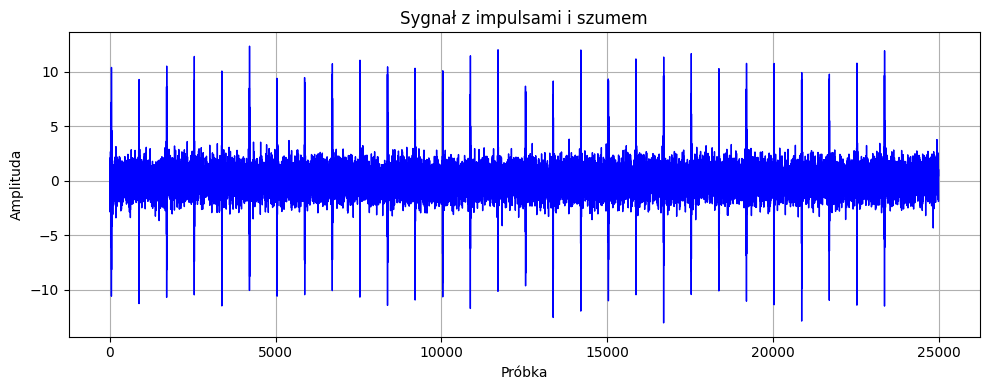

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(signal, color='blue', linewidth=1)
plt.title("Sygnał z impulsami i szumem")
plt.xlabel("Próbka")
plt.ylabel("Amplituda")
plt.grid(True)
plt.tight_layout()
plt.show()

## Spektrogram

### Obliczenie krótkoczasowej transformaty Fouriera

In [17]:
fs = 25000
array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal, fs = fs, window = 'hann')
Zxx = np.abs(matrix_Zxx)

### Wyrysowanie wykresu

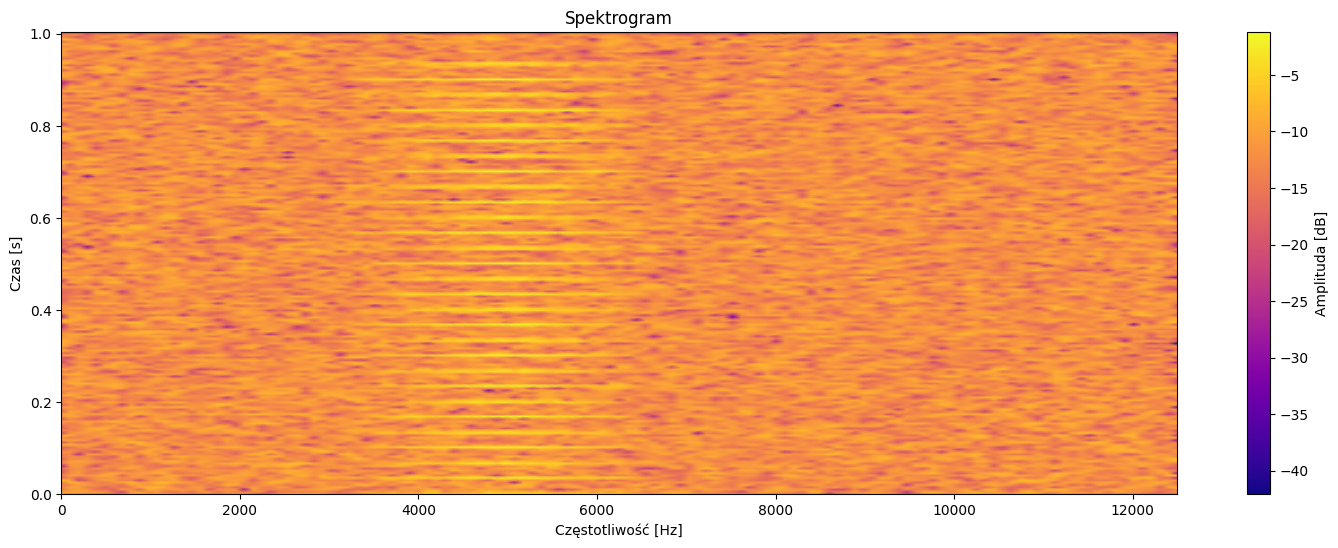

In [25]:

plt.figure(figsize=(18, 6))
plt.pcolormesh(array_freq, array_tt, 10*np.log10(Zxx.T), shading='gouraud', cmap='plasma')
plt.xlabel('Częstotliwość [Hz]')
plt.ylabel('Czas [s]')
plt.title('Spektrogram')
plt.colorbar(label='Amplituda [dB]')
plt.show()

# Selektory

In [19]:
import ifb_selectors as selector

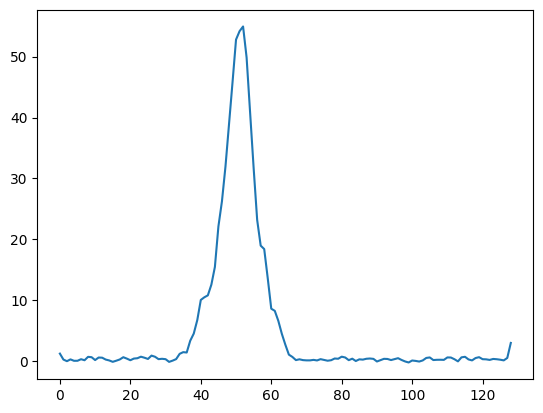

In [20]:
sk_results = selector.SK(Zxx)
plt.plot(sk_results)

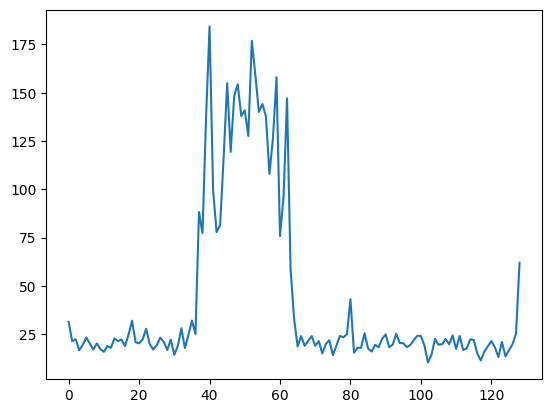

In [21]:
jb_results = selector.JB(Zxx)
plt.plot(jb_results)

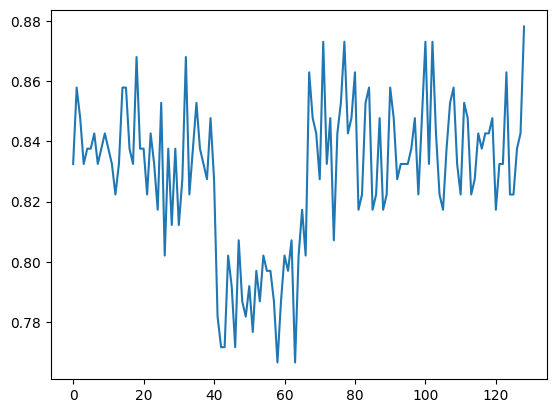

In [22]:
kss_results = selector.KSS(Zxx)
plt.plot(1/kss_results)

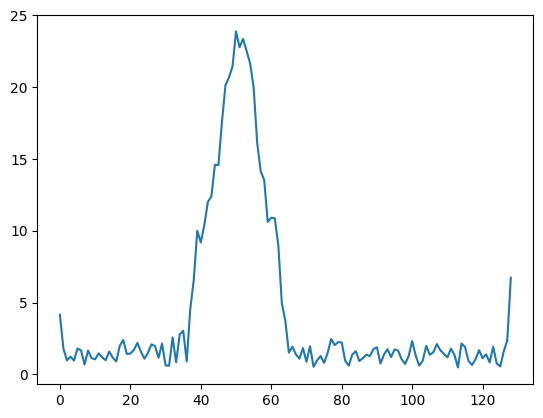

In [23]:
ad_results = selector.AD(Zxx)
plt.plot(ad_results)

## Faktyczne obliczenie wszystkich selektorów


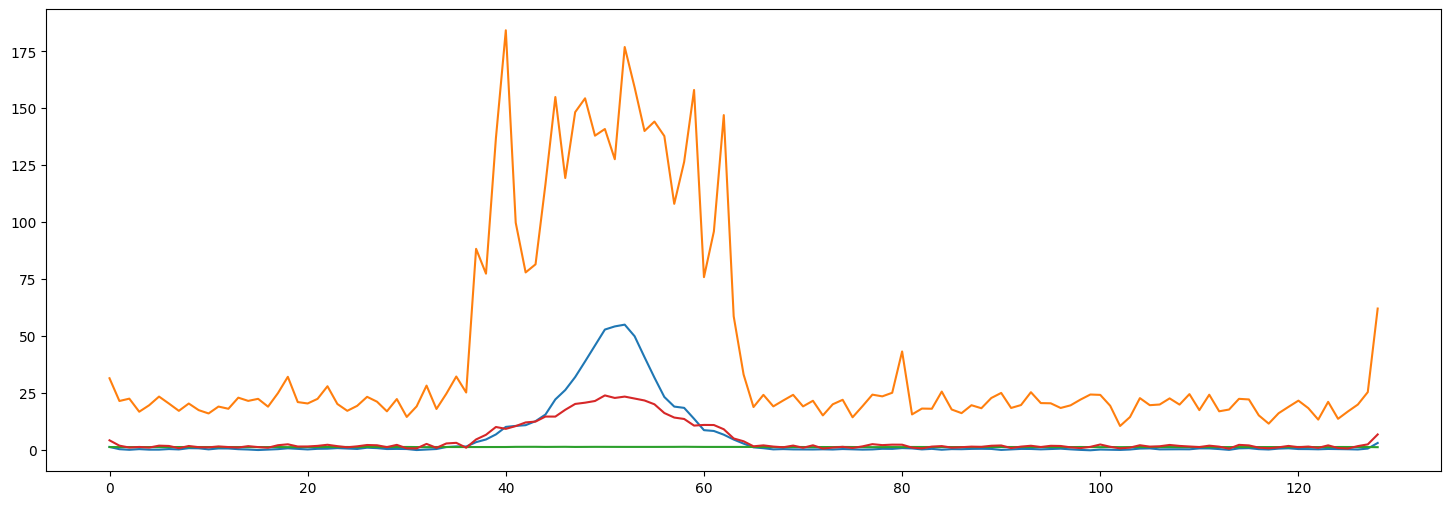

In [29]:
sk_results = selector.SK(Zxx)
jb_results = selector.JB(Zxx)
kss_results = selector.KSS(Zxx)
ad_results = selector.AD(Zxx)

plt.figure(figsize=(18, 6))
plt.plot(sk_results)
plt.plot(jb_results)
plt.plot(kss_results)
plt.plot(ad_results)